In [1]:
import sys
import os
import glob
import numpy as np
import librosa
import matplotlib.pyplot as plt

In [2]:
def audio_list_to_vector_array(file_list):
    vector_array = []
    for audio_file in file_list:
        y, sr = librosa.load(audio_file, sr=None, mono=True)
        vector_array.append([y, sr])
    return vector_array

def visualize_audio_as_waveform(audio_vector_array, index):
    plt.figure().set_figwidth(12)
    librosa.display.waveshow(audio_vector_array[index][0], sr=audio_vector_array[index][1])

def audio_list_to_frequency_spectrum(vector_array):
    frequency_vector_array = []
    for audio in vector_array:
        dft_input = audio[0]
        window = np.hanning(len(dft_input))
        windowed_input = dft_input * window
        dft = np.fft.rfft(windowed_input)

        amplitude = np.abs(dft)
        amplitude_db = librosa.amplitude_to_db(amplitude, ref=np.max)

        frequency = librosa.fft_frequencies(sr=audio[1], n_fft=len(dft_input))

        frequency_vector_array.append([frequency, amplitude_db])

    return frequency_vector_array

def visualize_audio_as_frequency_spectrum(frequency_vector_array, index):
    plt.figure().set_figwidth(12)
    plt.plot(frequency_vector_array[index][0], frequency_vector_array[index][1])
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude (dB)")
    plt.xscale("log")

def audio_list_to_spectrogram(vector_array):
    spectrogram_vector_array = []
    for audio in vector_array:
        D = librosa.stft(audio[0])
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

        spectrogram_vector_array.append(S_db)

    return spectrogram_vector_array

def visualize_audio_as_spectrogram(spectrogram_vector_array, index):
    plt.figure().set_figwidth(12)
    librosa.display.specshow(spectrogram_vector_array[index], x_axis="time", y_axis="hz")
    plt.colorbar()

def audio_list_to_mel_spectrogram(vector_array):
    mel_vector_array = []
    for audio in vector_array:
        S = librosa.feature.melspectrogram(y=audio[0], sr=audio[1], n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)

        mel_vector_array.append([S_dB, audio[1]])

    return mel_vector_array

def visualize_audio_as_mel_spectrogram(mel_vector_array, index):
    plt.figure().set_figwidth(12)
    librosa.display.specshow(mel_vector_array[index][0], x_axis="time", y_axis="mel", sr=mel_vector_array[index][1], fmax=30000)
    plt.colorbar()

In [3]:
def list_wavs_by_machine_id(path, machine_id):
    training_list_path = os.path.relpath("../dataset/{dir}/*_id_{id}_*.wav".format(dir=path, id=machine_id))
    files = sorted(glob.glob(training_list_path))
    return files

In [5]:
files_id_2 = list_wavs_by_machine_id("fan/train", "02")
vector_array = audio_list_to_vector_array(files_id_2)
frequency_vector_array = audio_list_to_frequency_spectrum(vector_array)
spectrogram_vector_array = audio_list_to_spectrogram(vector_array)
mel_vector_array = audio_list_to_mel_spectrogram(vector_array)

In [6]:
from IPython.display import Audio

index = 10
Audio(data=vector_array[index][0], rate=vector_array[index][1])

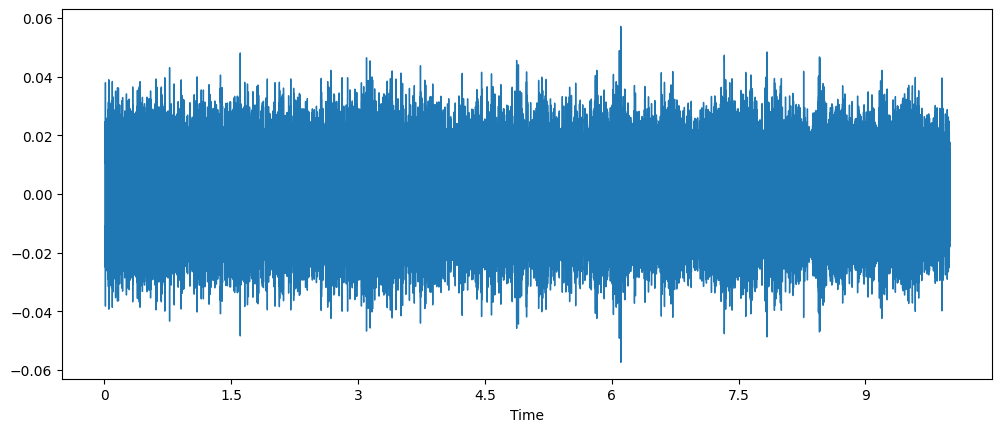

In [7]:
visualize_audio_as_waveform(vector_array, 0)

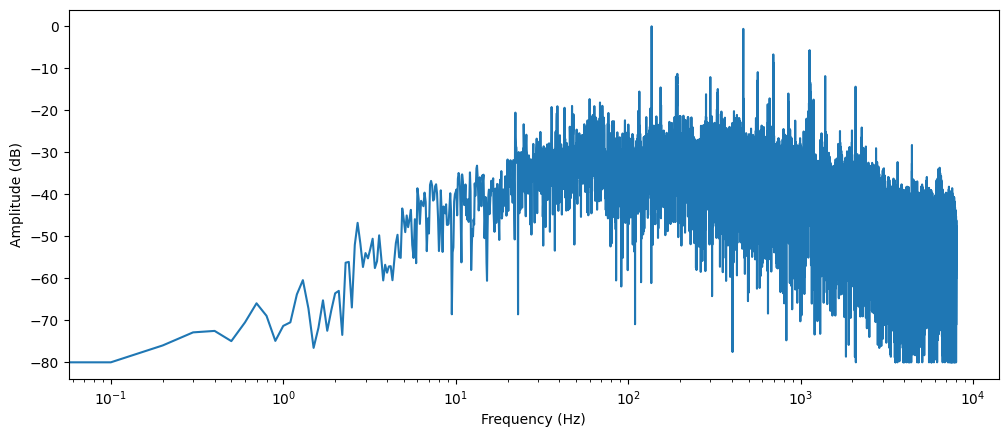

In [8]:
visualize_audio_as_frequency_spectrum(frequency_vector_array, 0)

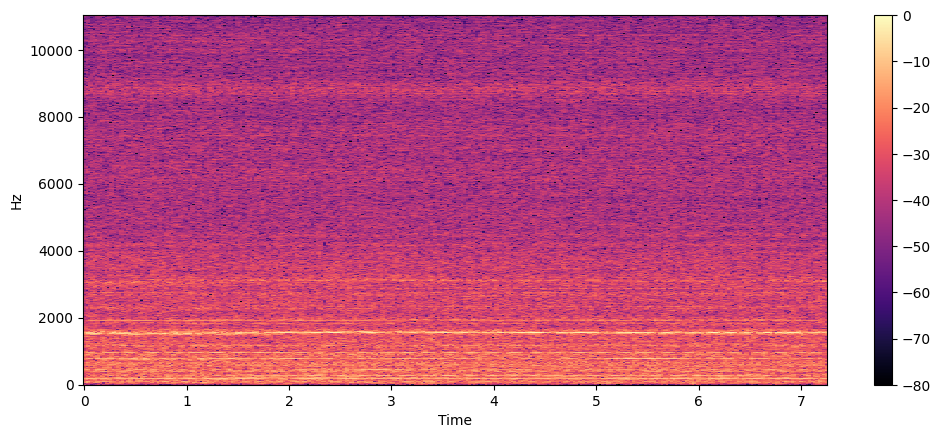

In [9]:
visualize_audio_as_spectrogram(spectrogram_vector_array, 0)

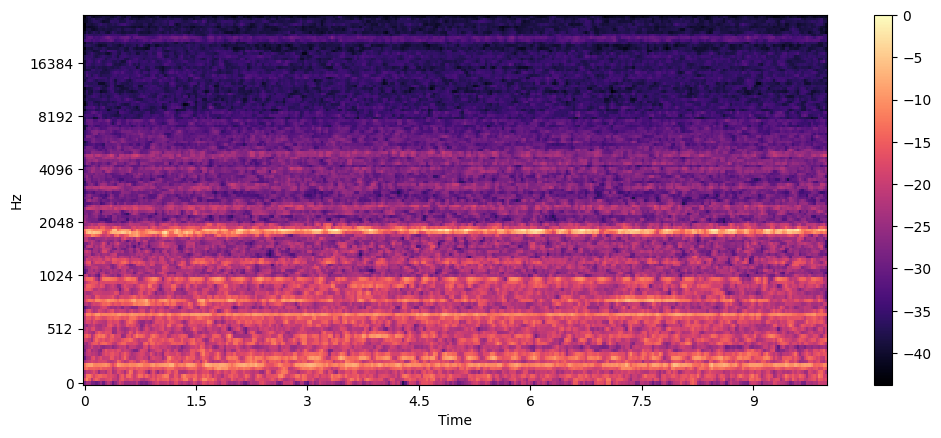

In [10]:
visualize_audio_as_mel_spectrogram(mel_vector_array, 0)